In [184]:
#%% Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import math
from PIL import Image
from matplotlib.ticker import MaxNLocator

from scipy.signal import welch
from scipy.optimize import curve_fit
import re
from scipy.signal import savgol_filter
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Circle
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from numba import njit, jit

In [10]:
# Lattice vectors
d1 = np.array([0, 1])
d2 = np.array([np.sqrt(3)/2, -1/2])
d3 = np.array([-np.sqrt(3)/2, -1/2])
delta = [d1, d2, d3]
delta = np.array(delta)

v1 = d2 - d3 
v2 = d3 - d1 
v3 = d1 - d2 
nn_delta = [v1, v2, v3]
nn_delta = np.array(nn_delta)

## Band Structure

In [ ]:
def haldane_hamiltonian(k, t1, t2, phi, M):

    k = np.array(k)
    kx, ky = k[0], k[1]
    
    f_k = 0
    for d in delta:
        f_k += np.exp(1j * (k @ d))
    
    dx = t1 * np.real(f_k)
    dy = -t1 * np.imag(f_k)
    
    H00 = M - 2 * t2 * np.sin(phi) * (np.sin(k @ nn_delta[0]) + np.sin(k @ nn_delta[1]) +np.sin(k @ nn_delta[2]))
    H11 = -H00
    H01 = dx - 1j*dy
    H10 = dx + 1j*dy
    H = np.array([[H00, H01], [H10, H11]]) # Hamiltonian definition
    Bands = [((H11+H00)+np.sqrt((H11-H00)**2+4*H01*H10)).real/2,((H11+H00)-np.sqrt((H11-H00)**2+4*H01*H10)).real/2]

    # Calculating derivatives of Hamiltonian (see last comment of this function)

    df_dkx = sum(1j * d[0] * np.exp(1j * (k @ d)) for d in delta)
    df_dky = sum(1j * d[1] * np.exp(1j * (k @ d)) for d in delta)
    
    ddx_dkx, ddy_dkx = t1 * np.real(df_dkx), -t1 * np.imag(df_dkx)
    ddx_dky, ddy_dky = t1 * np.real(df_dky), -t1 * np.imag(df_dky)

    dsin_dkx = sum(v[0] * np.cos(k @ v) for v in nn_delta)
    dsin_dky = sum(v[1] * np.cos(k @ v) for v in nn_delta)
    
    ddz_dkx = -2 * t2 * np.sin(phi) * dsin_dkx
    ddz_dky = -2 * t2 * np.sin(phi) * dsin_dky
    
    dH_dkx = np.array([[ddz_dkx, ddx_dkx - 1j*ddy_dkx],
                       [ddx_dkx + 1j*ddy_dkx, -ddz_dkx]])
    
    dH_dky = np.array([[ddz_dky, ddx_dky - 1j*ddy_dky],
                       [ddx_dky + 1j*ddy_dky, -ddz_dky]])
    
    return Bands, H, dH_dkx, dH_dky  # Additional outputs are taken from this function for use in code of further questions



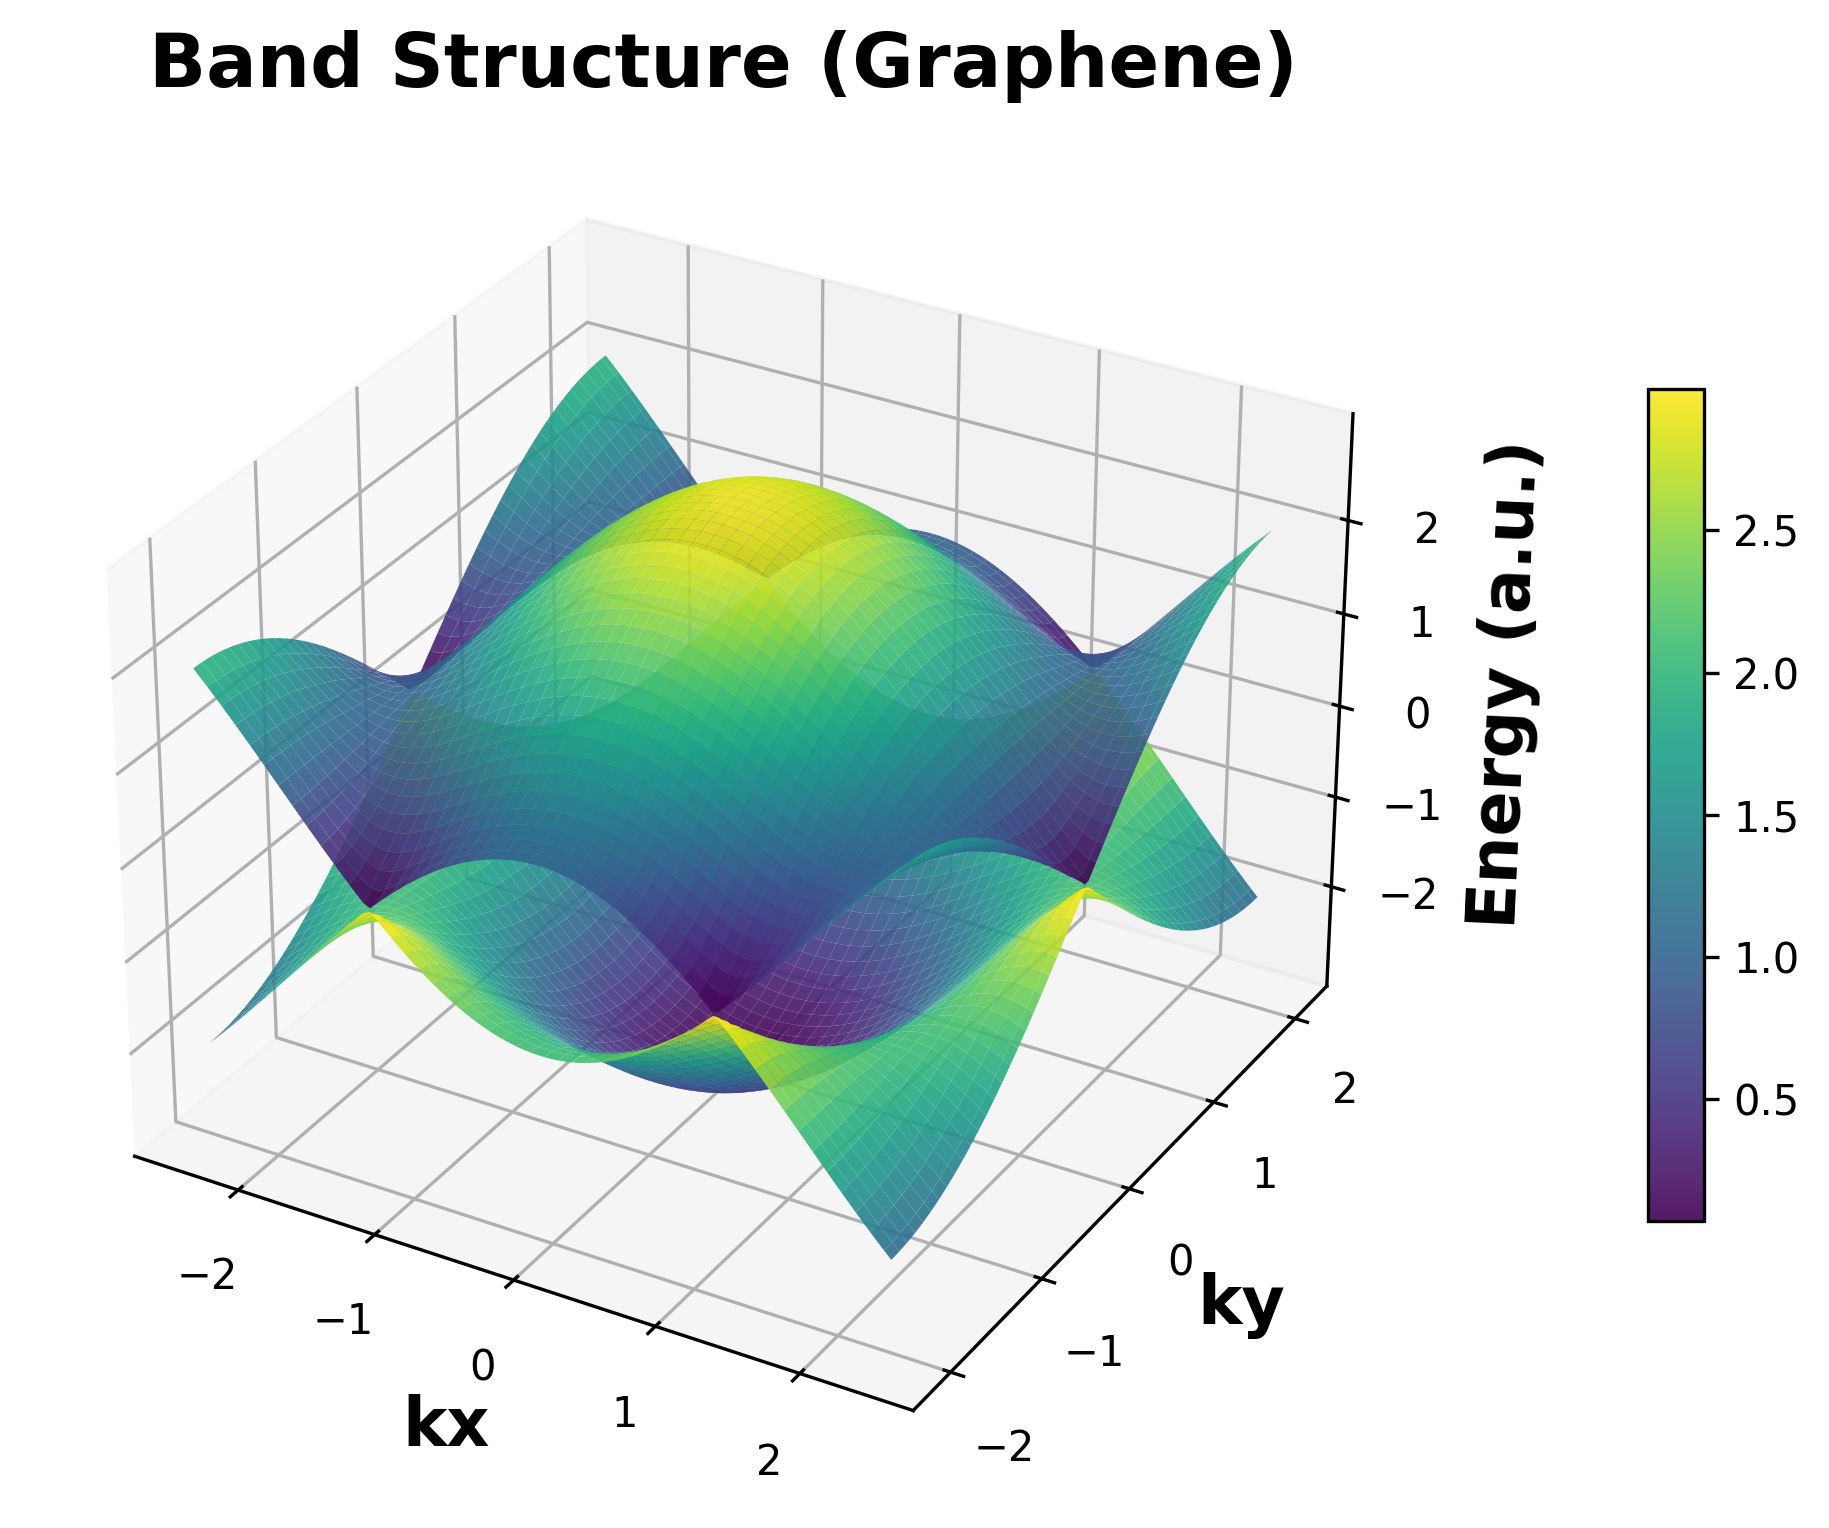

In [59]:
# Band structure of Graphene for code verification

N = 100

ky_array = np.linspace(-2*np.pi/(3),2*np.pi/(3),N)
kx_array = np.linspace(-4*np.pi/(3*np.sqrt(3)),4*np.pi/(3*np.sqrt(3)),N)
kX, kY = np.meshgrid(kx_array,ky_array)

Eband1 = np.zeros((kX.shape[0],kX.shape[1]))
Eband2 = np.zeros((kY.shape[0],kY.shape[1]))
for i in range(kX.shape[0]):
  for j in range(kY.shape[1]):
    E, _, x, y = haldane_hamiltonian([kX[i,j],kY[i,j]], 1, 0, 0, 0)
    Eband1[i,j] = E[0]
    Eband2[i,j] = E[1]

fig = plt.figure(figsize=(10,6), dpi=300)
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(kX, kY, Eband1,
                       cmap='viridis',
                       alpha=0.9,
                       linewidth=0,
                       antialiased=True)

ax.plot_surface(kX, kY, Eband2,
                cmap='viridis',
                alpha=0.9,
                linewidth=0,
                antialiased=True)

ax.set_xlabel('kx', fontsize=16, fontweight='bold')
ax.set_ylabel('ky', fontsize=16, fontweight='bold')
ax.set_zlabel('Energy (a.u.)', fontsize=16, fontweight='bold')
ax.set_title('Band Structure (Graphene)', fontsize=18, fontweight='bold')
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)

# Colorbar label
# cbar.set_label('Energy (a.u.)', fontsize=14, fontweight='bold')

plt.show()

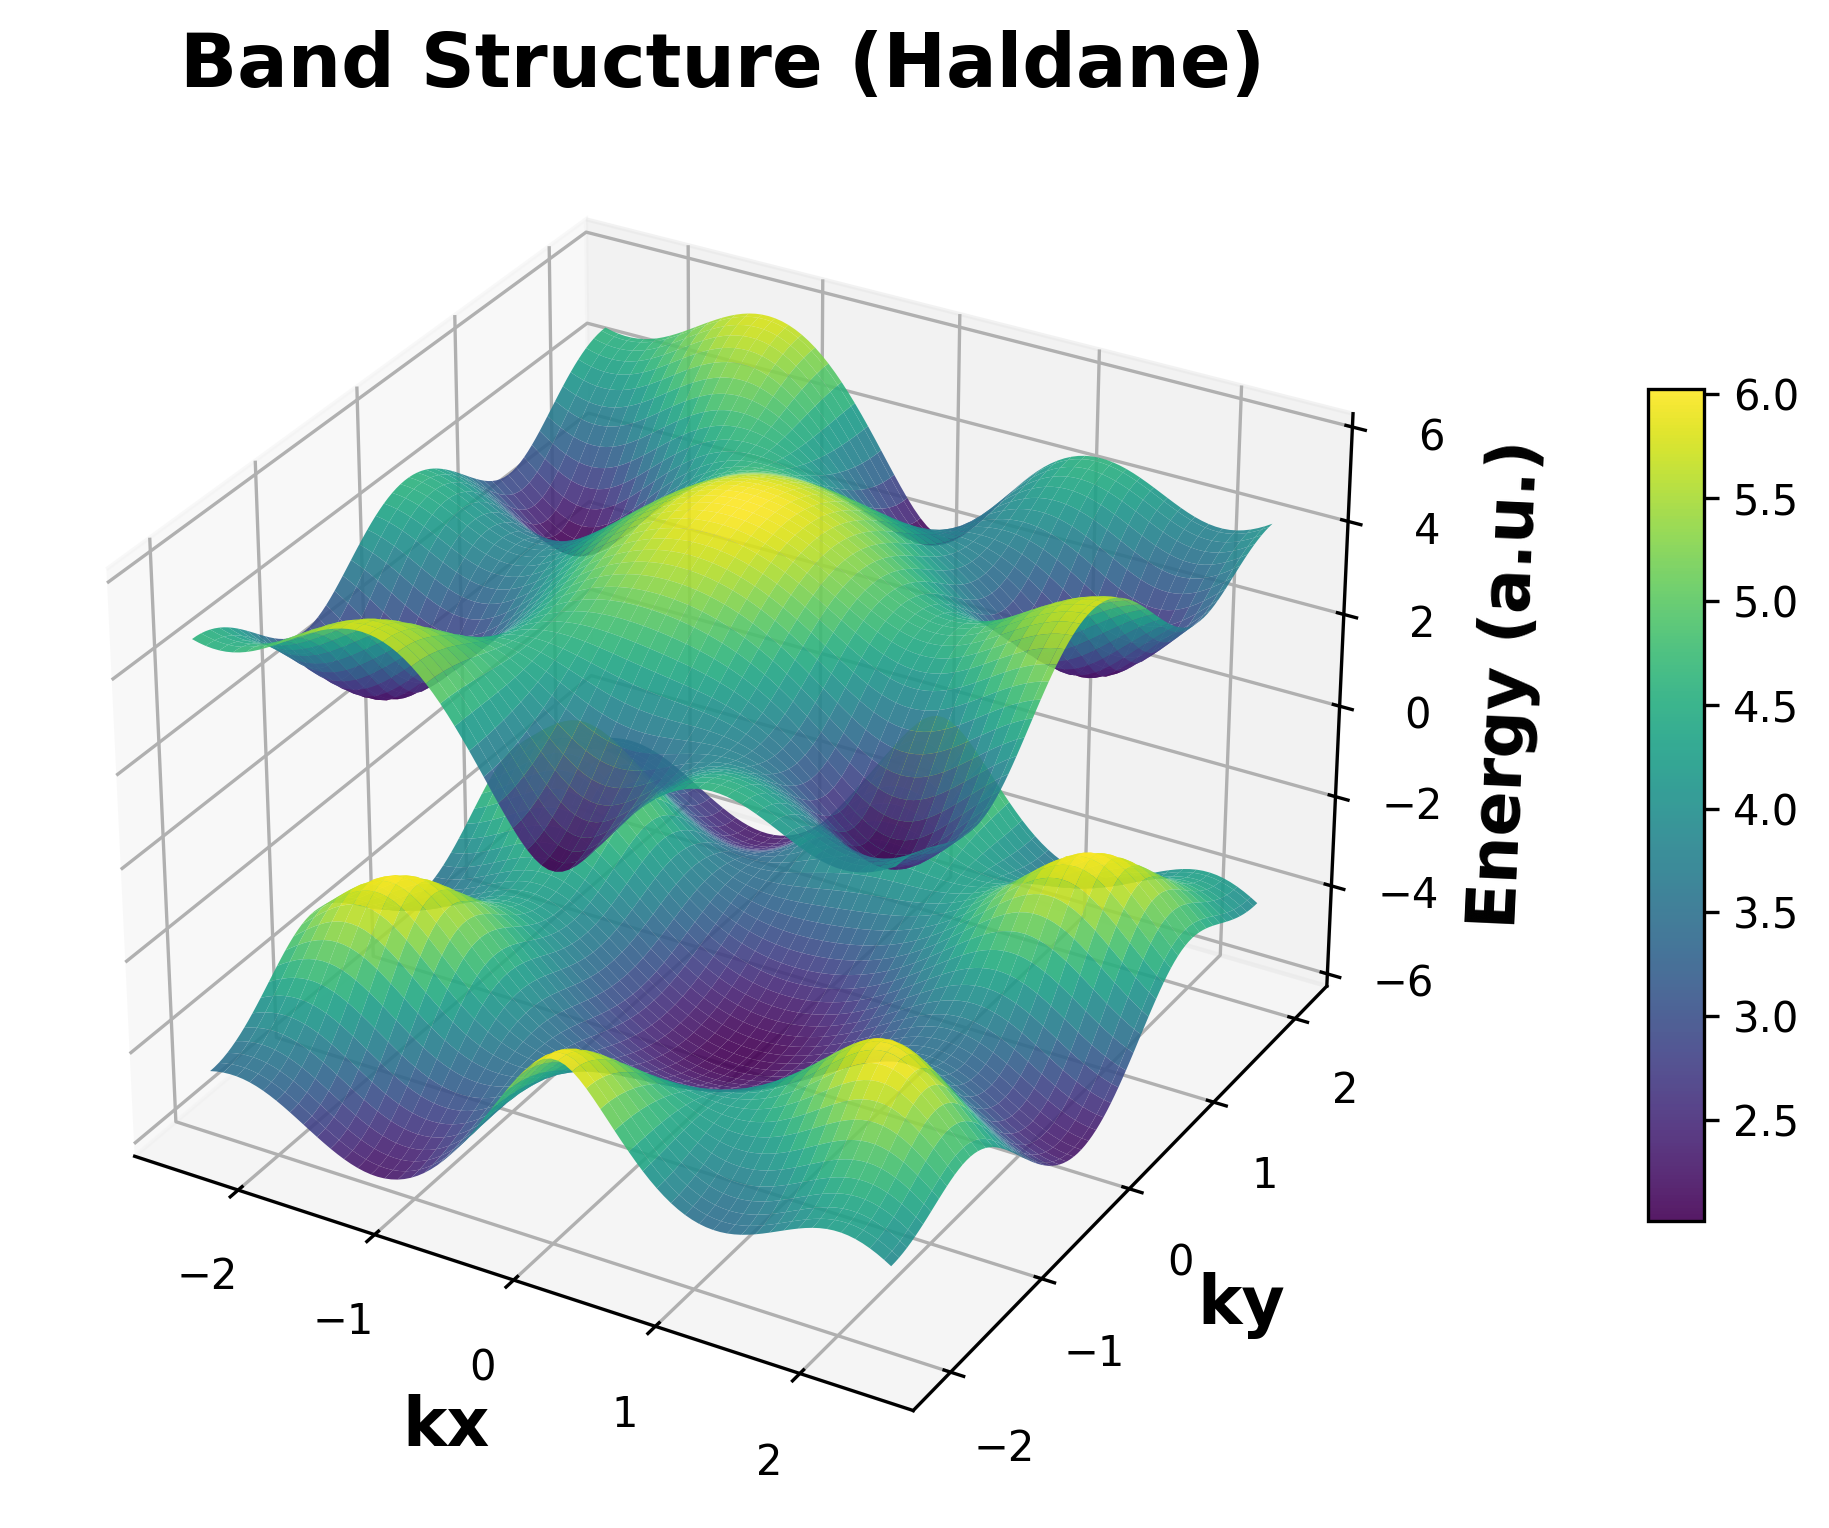

In [53]:
# Band structure of Haldane

N = 100

ky_array = np.linspace(-2*np.pi/(3),2*np.pi/(3),N)
kx_array = np.linspace(-4*np.pi/(3*np.sqrt(3)),4*np.pi/(3*np.sqrt(3)),N)
kX, kY = np.meshgrid(kx_array,ky_array)

Eband1 = np.zeros((kX.shape[0],kX.shape[1]))
Eband2 = np.zeros((kY.shape[0],kY.shape[1]))
for i in range(kX.shape[0]):
  for j in range(kY.shape[1]):
    E, _, x, y = haldane_hamiltonian([kX[i,j],kY[i,j]], 1, 0.5, np.pi/2, 0.3)
    Eband1[i,j] = E[0]
    Eband2[i,j] = E[1]

fig = plt.figure(figsize=(10,6), dpi=300)
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(kX, kY, Eband1,
                       cmap='viridis',
                       alpha=0.9,
                       linewidth=0,
                       antialiased=True)

ax.plot_surface(kX, kY, Eband2,
                cmap='viridis',
                alpha=0.9,
                linewidth=0,
                antialiased=True)

ax.set_xlabel('kx', fontsize=16, fontweight='bold')
ax.set_ylabel('ky', fontsize=16, fontweight='bold')
ax.set_zlabel('Energy (a.u.)', fontsize=16, fontweight='bold')
ax.set_title('Band Structure (Haldane)', fontsize=18, fontweight='bold')
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)

# Colorbar label
# cbar.set_label('Energy (a.u.)', fontsize=14, fontweight='bold')

plt.show()

## Berry Curvature

In [198]:
def get_curvature(k, t1, t2, phi, M):

    bands, H, dH_x, dH_y = haldane_hamiltonian(k, t1, t2, phi, M)
    eigenvalues, eigenvectors = np.linalg.eigh(H)

    # bands = np.array(bands)
    # print(bands)
    # print(eigenvalues)
    
    E_1 = eigenvalues[1]
    u_1 = eigenvectors[:,1]
    E_0 = eigenvalues[0]
    u_0 = eigenvectors[:,0]

    # The derived formula for Berry curvature is used here as taught in class
    omega = -2 * np.imag((np.dot(u_0.conj(), np.dot(dH_x, u_1))) * (np.dot(u_1.conj(), np.dot(dH_y, u_0))) / (E_0 - E_1)**2)
    return omega

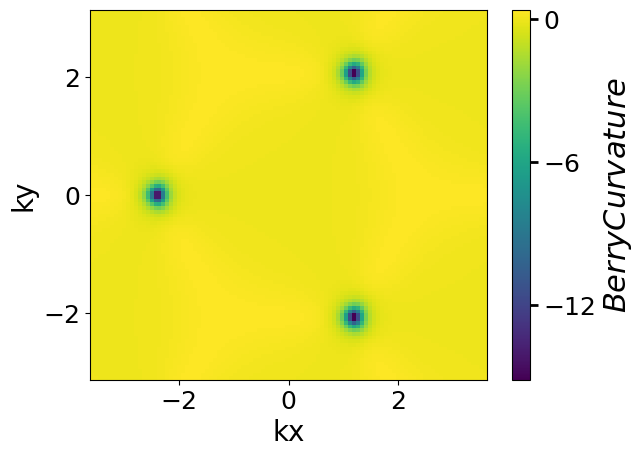

In [204]:
N = 100

ky_array = np.linspace(-3*np.pi/(3),3*np.pi/(3),N)
kx_array = np.linspace(-6*np.pi/(3*np.sqrt(3)),6*np.pi/(3*np.sqrt(3)),N)
kX, kY = np.meshgrid(kx_array,ky_array)

omega = np.zeros((kX.shape[0],kX.shape[1]))
for i in range(kX.shape[0]):
  for j in range(kY.shape[1]):
    omega[i,j] = get_curvature([kX[i,j],kY[i,j]], 1, 0.2, np.pi/4, 1)

plt.figure()
plt.imshow(omega,origin='lower',cmap='viridis',aspect='auto',extent=[kX.min(), kX.max(), kY.min(), kY.max()])
cbar = plt.colorbar()
cbar.set_label('$Berry Curvature$', size = 22)
plt.xlabel('kx', size = 20)#, fontweight='bold')
plt.ylabel('ky', size = 20)#, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.gca().xaxis.set_major_locator(MaxNLocator(4))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
cbar.locator = MaxNLocator(3)
cbar.ax.tick_params(labelsize=18, length=6, width=2)
cbar.update_ticks()
# plt.savefig("Gamma_y.svg", format="svg", bbox_inches="tight")
plt.show()

## Chern Number

In [200]:
def get_chern_number(t1, t2, phi, M, N):
    
    b1 = np.array([2*np.pi/np.sqrt(3), 2*np.pi/3])
    b2 = np.array([-2*np.pi/np.sqrt(3), 2*np.pi/3])

    u_vals = np.linspace(0,1,N)
    v_vals = np.linspace(0,1,N)

    du = u_vals[1]-u_vals[0]
    dv = v_vals[1]-v_vals[0]

    total = 0

    for u in u_vals:
        for v in v_vals:
            k = u*b1 + v*b2
            total += get_curvature(k, t1, t2, phi, M)

    jacobian = abs(np.cross(b1,b2))

    chern = total * du * dv * jacobian / (2*np.pi)

    return chern


In [210]:
# Result
get_chern_number(1, -0.3, np.pi/4, 0.5, 100)
# Rounding off the value from this function: We will not get exact integers since there will always be discretization in numerical simulations.
# Values mentioned in the report are rounded off.

-1.0100730400937312

## Topological Phase Diagram

In [174]:
from tqdm import tqdm

50it [00:09,  5.00it/s]
50it [00:10,  4.85it/s]
50it [00:10,  4.97it/s]
50it [00:10,  4.87it/s]
50it [00:10,  4.90it/s]
50it [00:09,  5.03it/s]
50it [00:10,  4.96it/s]
50it [00:10,  4.88it/s]
50it [00:10,  4.98it/s]
50it [00:09,  5.03it/s]
50it [00:10,  4.79it/s]
50it [00:09,  5.01it/s]
50it [00:10,  4.79it/s]
50it [00:10,  4.87it/s]
50it [00:10,  4.86it/s]
50it [00:09,  5.01it/s]
50it [00:10,  4.93it/s]
50it [00:09,  5.46it/s]
50it [00:07,  6.29it/s]
50it [00:08,  6.21it/s]
50it [00:08,  6.23it/s]
50it [00:08,  6.11it/s]
50it [00:08,  6.14it/s]
50it [00:08,  5.90it/s]
50it [00:09,  5.08it/s]
50it [00:08,  5.62it/s]
50it [00:09,  5.22it/s]
50it [00:09,  5.32it/s]
50it [00:09,  5.12it/s]
50it [00:09,  5.20it/s]
50it [00:09,  5.36it/s]
50it [00:08,  5.62it/s]
50it [00:09,  5.33it/s]
50it [00:09,  5.26it/s]
50it [00:09,  5.11it/s]
50it [00:09,  5.28it/s]
50it [00:09,  5.05it/s]
50it [00:09,  5.34it/s]
50it [00:09,  5.32it/s]
50it [00:09,  5.19it/s]
50it [00:09,  5.16it/s]
50it [00:09,  5.

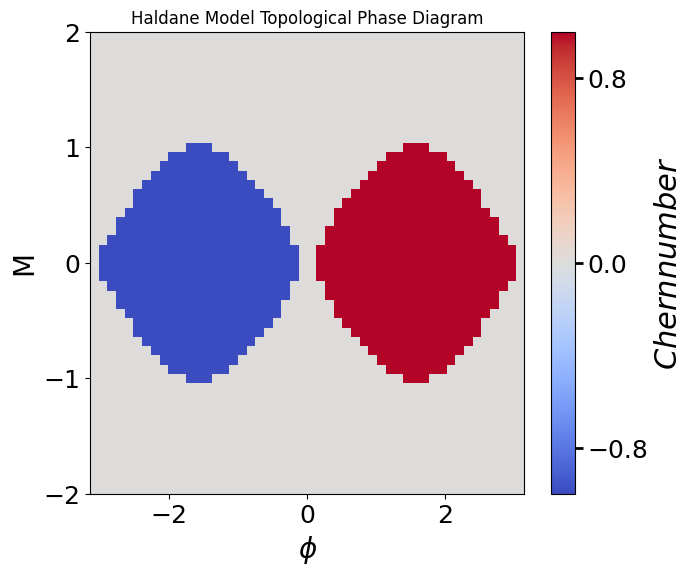

In [213]:
M_vals = np.linspace(-2,2,50)
phi_vals = np.linspace(-np.pi,np.pi,50)

chern = np.zeros((len(M_vals),len(phi_vals)))

for i,M in tqdm(enumerate(M_vals)):
    for j,phi in tqdm(enumerate(phi_vals)):
        chern[i,j] = round(get_chern_number(1, 0.2, phi, M, N=20))

plt.figure(figsize=(7,6))

plt.imshow(chern,extent=[phi_vals.min(),phi_vals.max(),M_vals.min(),M_vals.max()],origin='lower',aspect='auto',cmap='coolwarm')

cbar = plt.colorbar()
cbar.set_label('$Chern number$', size = 22)
plt.xlabel(r"$\phi$", size = 20)#, fontweight='bold')
plt.ylabel('M', size = 20)#, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.gca().xaxis.set_major_locator(MaxNLocator(4))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
cbar.locator = MaxNLocator(3)
cbar.ax.tick_params(labelsize=18, length=6, width=2)
cbar.update_ticks()
# plt.savefig("Gamma_y.svg", format="svg", bbox_inches="tight")
plt.title("Haldane Model Topological Phase Diagram")
plt.show()

Last question answered completely in report.